##Instalación de Librerías y Definición del Ambiente


Las siguientes librerías se usan a lo largo de este notebook.



```numpy``` Se usa para manejar datos de tipo array, una necesidad también para las imágenes del ambiente quqndo se convierten en datos tipo array.

```time``` para medir la duración real, medida en tiempo real, de nuestras sesiones de entrenamiento.

```base64``` Esta biblioteca nos sirvió como fuente principal de implementaciones fiables de algoritmos de aprendizaje por refuerzo.

```imageio``` Para capturar los resultados de nuestro entrenamiento en un formato visual.

```torch``` Un marco de aprendizaje profundo fundamental para construir y optimizar las arquitecturas de redes neuronales que impulsan los procesos de toma de decisiones de nuestros agentes.





In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!apt-get update && apt-get install -y swig python3-dev

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.2 kB]
Get:10 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,436 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:13 https://ppa.launchpadcontent.net/graphics-driver

In [ ]:
!pip install "gymnasium[box2d,mujoco,robotics]"
!pip install imageio pyvirtualdisplay stable-baselines3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 4.8 MB/s eta 0:00:00


In [ ]:
from pyvirtualdisplay import Display
# Para mostrar video
from IPython.display import HTML, clear_output
from base64 import b64encode
!pip install gymnasium-robotics
# Librerías básicas
import gymnasium as gym
import imageio
import os
import time
import gymnasium_robotics
import torch # Import torch library

#Limpia los registros generados
from IPython.display import clear_output

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.2/26.2 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.5/852.5 kB 49.6 MB/s eta 0:00:00


In [ ]:
from stable_baselines3 import PPO
#from sb3_contrib import TRPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3 import DDPG
from stable_baselines3 import TD3
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.noise import NormalActionNoise #Función para incorporar ruido
from stable_baselines3 import SAC
from stable_baselines3 import A2C

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Utilizamos estos modelos para conectar los datos ambientales brutos con la toma de decisiones inteligentes en simulaciones complejas. Mediante la implementación del algoritmo de Optimización de Políticas Proximal (PPO), garantizamos la estabilidad y fiabilidad del proceso de aprendizaje de nuestro agente, evitando los cambios drásticos de política que suelen afectar al aprendizaje por refuerzo. Nos basamos en estas arquitecturas específicas porque nos permiten equilibrar eficazmente la exploración y la explotación, asegurando que nuestro agente no se conforme con la primera solución que encuentre, sino que perfeccione continuamente su estrategia. En definitiva, al monitorizar estas curvas de entrenamiento y ajustar nuestros hiperparámetros, desarrollamos un sistema capaz de dominar tareas físicas complejas mediante una mejora iterativa basada en datos.

In [ ]:
import matplotlib.pyplot as plt
class RewardLoggerCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []  # Lista para almacenar las recompensas por episodio
        self.episode_reward = 0    # Acumulador de recompensa para el episodio actual

    def _on_step(self) -> bool:
        # Si hay recompensas disponibles en el paso actual, se suman al acumulador
        if "rewards" in self.locals:
            self.episode_reward += self.locals["rewards"][0]
        # Si el episodio ha terminado, se guarda la recompensa acumulada y se reinicia el contador
        if "dones" in self.locals and self.locals["dones"][0]:
            self.episode_rewards.append(self.episode_reward)
            self.episode_reward = 0
        return True


# Clase para entrenar un agente en el entorno HandReachDense-v3
class FingerTrainer:
    def __init__(self, model_fn, total_timesteps=130_000, log_dir="./hopper_logs"):
        self.total_timesteps = total_timesteps
        self.log_dir = log_dir
        os.makedirs(log_dir, exist_ok=True)  # Crear el directorio de logs si no existe

        # Iniciar una pantalla virtual (necesaria en Colab o entornos sin interfaz gráfica)
        self.display = Display(visible=0, size=(1400, 900))
        self.display.start()

        # Crear el entorno Hopper vectorizado
        self.env = make_vec_env("HandReachDense-v3", n_envs=1)

        # Crear el modelo usando la función proporcionada
        self.model = model_fn(self.env)

        # Inicializar el callback para registrar recompensas
        self.callback = RewardLoggerCallback()


    def train(self, save_path="ppo_door_model"):
        print("GPU available?", torch.cuda.is_available())
        if torch.cuda.is_available():
            print("Using device:", torch.cuda.get_device_name(0))

        start_time = time.time()
        # Entrenar el modelo con el número total de pasos y el callback
        self.model.learn(total_timesteps=self.total_timesteps, callback=self.callback)
        elapsed = time.time() - start_time

        # Guardar el modelo entrenado
        self.model.save(save_path)
        print(f"Training complete. Model saved. Training took {elapsed:.2f} seconds.")

    def plot_rewards(self):
        # Verificar si hay datos de recompensa para graficar
        if not self.callback.episode_rewards:
            print("No reward data to plot.")
            return
        # Graficar las recompensas por episodio
        plt.figure(figsize=(10, 5))
        plt.plot(self.callback.episode_rewards, label="Episode Reward")
        plt.xlabel("Episodes")
        plt.ylabel("Reward")
        plt.title("Training Rewards Over Time")
        plt.grid()
        plt.legend()
        plt.tight_layout()
        plt.show()

    def generate_video(self, model, video_filename="Door_video.mp4"):
        # Crear entorno Hopper con renderizado RGB
        env = gym.make("HandReachDense-v3", render_mode="rgb_array")
        obs, info = env.reset()
        frames = []
        total_reward = 0
        terminated = truncated = False

        # Ejecutar el entorno hasta que termine
        while not (terminated or truncated):
            action, _ = model.predict(obs, deterministic=True)  # Predecir acción
            obs, reward, terminated, truncated, info = env.step(action)
            frame = env.render()  # Capturar fotograma
            frames.append(frame)
            total_reward += reward

        env.close()

        # Guardar el video como archivo MP4
        imageio.mimsave(video_filename, frames, fps=30)
        print("Total reward:", total_reward)

        # Mostrar el video en Colab
        mp4 = open(video_filename, "rb").read()
        data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

        return HTML(f"""
        <video width=600 controls>
            <source src="{data_url}" type="video/mp4">
        </video>
        """)

In [ ]:
display = Display(visible=0, size=(1400, 900))
display.start()

# Create FetchPickAndPlace environment with RGB rendering
env = gym.make("HandReachDense-v3", render_mode="rgb_array")
obs, info = env.reset(seed=42)

frames = []
terminated = truncated = False
total_reward = 0

def policy(observation):
    # Dummy policy: zeros for all action dimensions (4D for Fetch)
    return env.action_space.sample()  # Replace with custom logic if needed

while not (terminated or truncated):
    action = policy(obs)
    obs, reward, terminated, truncated, info = env.step(action)
    frame = env.render()
    frames.append(frame)
    total_reward += reward

env.close()

# Save video
video_filename = "hand_reach.mp4"
imageio.mimsave(video_filename, frames, fps=30)

print("Video saved to:", video_filename)
print("Total reward:", total_reward)

Video saved to: hand_reach.mp4
Total reward: -5.6035164655350185


Según el cuaderno proporcionado, el proceso de entrenamiento utiliza varios hiperparámetros clave para el modelo de aprendizaje por refuerzo. El cuaderno se centra principalmente en entrenar un agente mediante el algoritmo de optimización de políticas proximales (PPO).

## Hiperparámetros clave

* **Tasa de aprendizaje:** La tasa de aprendizaje se establece en 0,001 (o $1 \times 10^{-3}$) durante la mayor parte del proceso de entrenamiento. Los registros posteriores muestran un ajuste a 0,0007.

* **Pasos de tiempo totales:** El modelo se entrena con un gran número de interacciones, y los registros muestran un progreso de hasta 1.000.000 de pasos de tiempo.

* **Rango de recorte:** Se utiliza un valor de 0,2 para el parámetro de recorte de PPO, lo que ayuda a estabilizar el entrenamiento al limitar el cambio de política en cada paso.

* **Duración media del episodio:** El entrenamiento se configura con una duración media del episodio de 50 pasos.

* **Desviación estándar (std):** La desviación estándar de la distribución de acciones comienza alrededor de 1.0 y aumenta hasta aproximadamente 1.63 a medida que avanza el entrenamiento.

## Métricas de entrenamiento

El cuaderno también registra varias métricas internas de entrenamiento que reflejan la influencia de estos hiperparámetros:

* **Pérdida de entropía:** Mide la aleatoriedad de las acciones del agente; en los registros, oscila entre aproximadamente -28.2 y -37.8.

* **Varianza explicada:** Indica la precisión con la que la función de valor predice las recompensas. Los valores en los registros fluctúan, apareciendo a menudo cerca de -0.4 a -0.5 durante ciertas fases.

* **Fotogramas por segundo (FPS):** La eficiencia del entrenamiento en el hardware proporcionado (GPU Tesla T4) alcanzó aproximadamente entre 220 y 308 FPS.

In [ ]:
def create_model(env):
    return PPO(
        "MultiInputPolicy",
        env,
        verbose=1,
        device="cpu",
        learning_rate=0.001,
        n_steps=2048,
        policy_kwargs=dict(net_arch=dict(pi=[512, 512, 256], vf=[512, 512, 256]))
    )

trainer = FingerTrainer(model_fn=create_model, total_timesteps=300_000)
trainer.train(save_path="ppo_hand_reach_model") # Changed save_path

Using cpu device
GPU available? True
Using device: Tesla T4
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -6.53    |
|    success_rate    | 0        |
| time/              |          |
|    fps             | 313      |
|    iterations      | 1        |
|    time_elapsed    | 6        |
|    total_timesteps | 2048     |
---------------------------------
---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 50        |
|    ep_rew_mean          | -6.41     |
|    success_rate         | 0         |
| time/                   |           |
|    fps                  | 256       |
|    iterations           | 2         |
|    time_elapsed         | 15        |
|    total_timesteps      | 4096      |
| train/                  |           |
|    approx_kl            | 0.7603156 |
|    clip_fraction        | 0.803     |
|    clip_range           | 0.2       |
|    e

THe trainer falls to the high 4s but can't push lower than that

Total reward: -3.8568303943316855


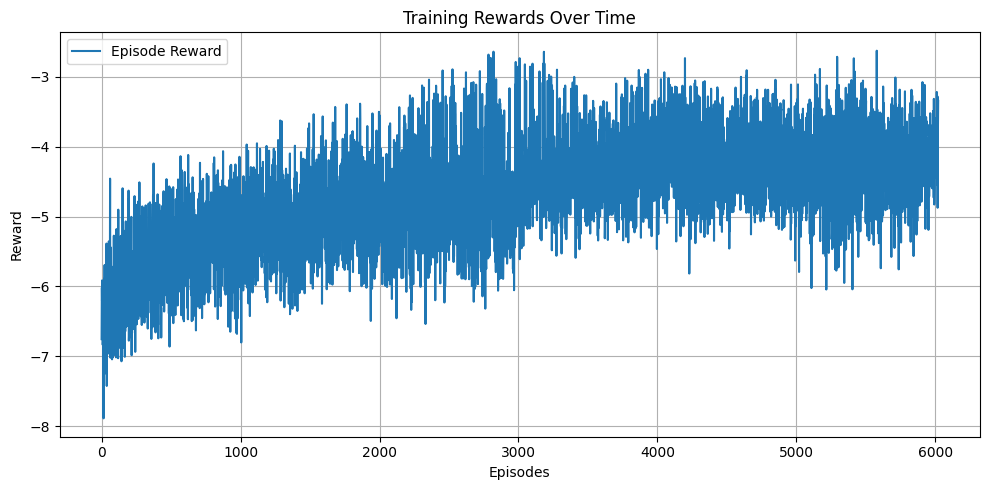

In [ ]:
from IPython.display import display # Explicitly import display

model = trainer.model
video_html = trainer.generate_video(model)
display(video_html)
trainer.plot_rewards()

In [ ]:
def create_model(env):
    return A2C(
        "MultiInputPolicy",
        env,
        verbose=1,
        device="cpu",
        learning_rate=0.001,
        n_steps=2048,
        policy_kwargs=dict(net_arch=dict(pi=[512, 512, 256], vf=[512, 512, 256]))
    )

trainer = FingerTrainer(model_fn=create_model, total_timesteps=300_000)
trainer.train()

Using cpu device
GPU available? True
Using device: Tesla T4
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 50       |
|    ep_rew_mean        | -3.72    |
|    success_rate       | 0        |
| time/                 |          |
|    fps                | 308      |
|    iterations         | 100      |
|    time_elapsed       | 663      |
|    total_timesteps    | 204800   |
| train/                |          |
|    entropy_loss       | -28.2    |
|    explained_variance | 0.00126  |
|    learning_rate      | 0.001    |
|    n_updates          | 99       |
|    policy_loss        | -1.55    |
|    std                | 0.992    |
|    value_loss         | 0.0288   |
------------------------------------
Training complete. Model saved. Training took 971.90 seconds.


Total reward: -4.233414995059439


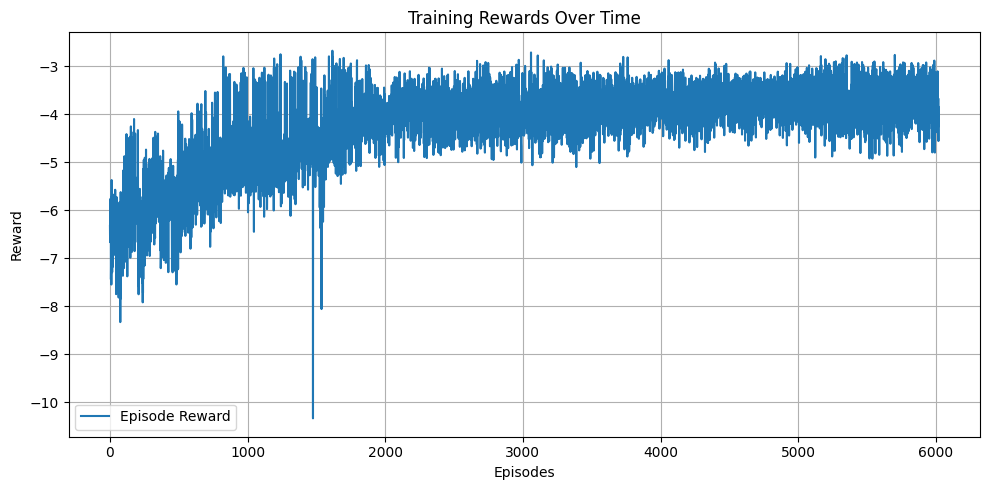

In [ ]:
model = trainer.model
video_html = trainer.generate_video(model)
display(video_html)
trainer.plot_rewards()

In [ ]:
def create_model(env):
    return DDPG(
        "MultiInputPolicy",
        env,
        verbose=1,
        device="cuda",
        learning_rate=0.001,
        n_steps=1,
        policy_kwargs=dict(net_arch=dict(pi=[512, 512, 256], qf=[512, 512, 256]))# Changed n_steps to 1 to support Dict observation spaces
    )

trainer = FingerTrainer(model_fn=create_model, total_timesteps=1_000_000)
trainer.train()

Using cuda device


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


GPU available? True
Using device: Tesla T4


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -8.52    |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 4        |
|    fps             | 78       |
|    time_elapsed    | 2        |
|    total_timesteps | 200      |
| train/             |          |
|    actor_loss      | 0.214    |
|    critic_loss     | 0.00108  |
|    learning_rate   | 0.001    |
|    n_updates       | 99       |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -10.8    |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 8        |
|    fps             | 70       |
|    time_elapsed    | 5        |
|    total_timesteps | 400      |
| train/             |          |
|    actor_loss      | 0.396    |
|    critic_loss     | 9.12e-05 |
|    learning_


KeyboardInterrupt



Total reward: -13.143068778828816


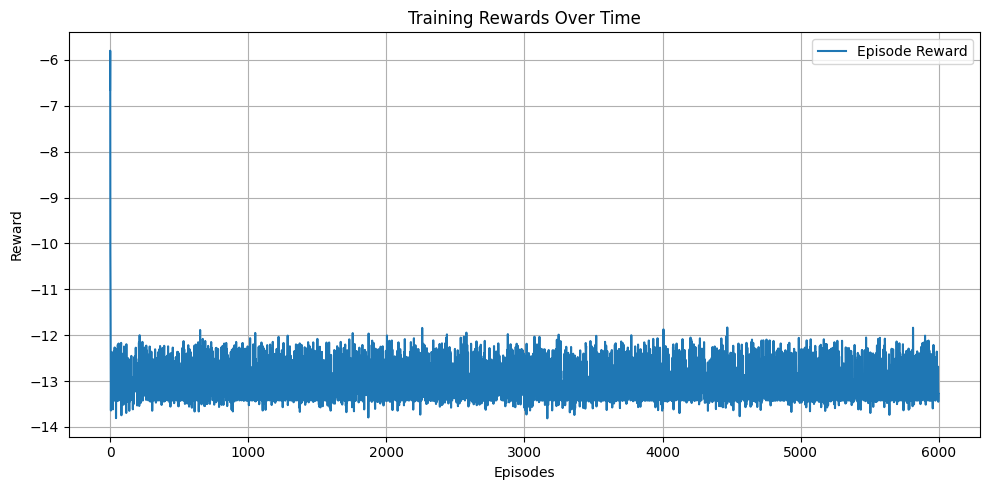

In [ ]:
model = trainer.model
video_html = trainer.generate_video(model)
display(video_html)
trainer.plot_rewards()

In [ ]:
def create_model(env):
    return TD3(
        "MultiInputPolicy",
        env,
        verbose=1,
        device="cuda",
        learning_rate=0.001,
        n_steps=1,
        policy_kwargs=dict(net_arch=dict(pi=[512,512, 256], qf=[512, 512, 256]))
    )
trainer = FingerTrainer(model_fn=create_model, total_timesteps=300_000)
trainer.train()

In [ ]:
model = trainer.model
video_html = trainer.generate_video(model)
display(video_html)
trainer.plot_rewards()

In [ ]:
def create_model(env):
    return TD3(
        "MultiInputPolicy",
        env,
        verbose=1,
        device="cuda",
        learning_rate=0.0007,
        n_steps=1,
        policy_kwargs=dict(net_arch=dict(pi=[512,512, 256], qf=[512, 512, 256]))
    )

trainer = FingerTrainer(model_fn=create_model, total_timesteps=1_000_000)
trainer.train()

Using cuda device


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


GPU available? True
Using device: Tesla T4


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Streaming output truncated to the last 5000 lines.
|    total_timesteps | 937600   |
| train/             |          |
|    actor_loss      | 2.61     |
|    critic_loss     | 0.000312 |
|    learning_rate   | 0.0007   |
|    n_updates       | 937499   |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -1.33    |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 18756    |
|    fps             | 87       |
|    time_elapsed    | 10680    |
|    total_timesteps | 937800   |
| train/             |          |
|    actor_loss      | 2.58     |
|    critic_loss     | 0.000347 |
|    learning_rate   | 0.0007   |
|    n_updates       | 937699   |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -1.33    |
|    success_rate    | 0       

Total reward: -0.8746886751164161


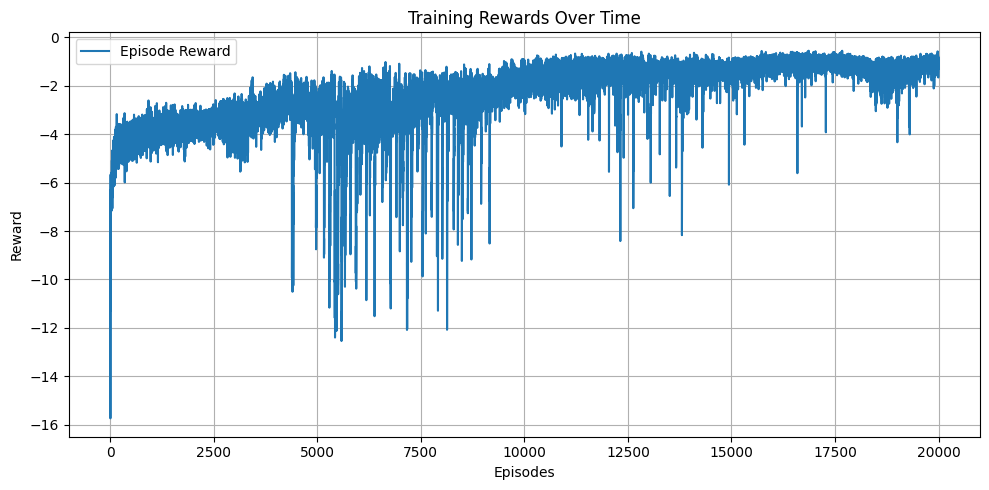

In [ ]:
model = trainer.model
video_html = trainer.generate_video(model)
display(video_html)
trainer.plot_rewards()

## Despliegue / Ep_Rew_Mean (Análisis de Recompensa)

Este es el gráfico más importante para determinar si tu agente está "aprendiendo".

* **Tendencia:** Se observa una trayectoria ascendente clara y constante. La recompensa media comienza en un valor muy negativo (alrededor de -150) y aumenta de forma constante hasta casi 0 al final del millón de pasos.

* **Interpretación:** El agente está aprendiendo con éxito a optimizar su comportamiento. Aún no ha "resuelto" completamente el entorno (lo que normalmente requiere una meseta de recompensa positiva), pero la ausencia de esta meseta sugiere que, si se continúa el entrenamiento más allá del millón de pasos, el rendimiento podría mejorar aún más.

## Entrenamiento / Pérdida (Estabilidad de la Optimización)
Este gráfico muestra que la función de pérdida total se está minimizando.

* **Tendencia:** La pérdida comienza alta y extremadamente volátil, para luego reducirse a un rango mucho más estrecho y bajo.

* **Interpretación:** Esto es una buena señal. Una pérdida inicial elevada es común, ya que el agente realiza "suposiciones" aleatorias. La forma de "cono" cada vez más estrecha indica que el modelo está convergiendo y que las actualizaciones de la política se están volviendo más estables.

## Entrenamiento / Pérdida de entropía
La entropía mide la "aleatoriedad" o exploración del agente.

* **Tendencia:** La entropía está disminuyendo (volviéndose más negativa).

* **Interpretación:** Esto significa que el agente está adquiriendo mayor confianza en sus acciones. Está pasando de la "exploración" (probar cosas al azar) a la "explotación" (utilizar lo que sabe que funciona). Dado que no se ha estabilizado en un valor muy bajo, el agente aún mantiene cierto nivel de curiosidad/variabilidad.

## Entrenamiento / Pérdida de gradiente de política y pérdida de valor
* **Pérdida de gradiente de política:** Muestra valores pequeños y oscilantes alrededor de cero. Esto es típico de PPO, ya que el mecanismo de recorte evita actualizaciones masivas y destructivas de la política.

* **Pérdida de valor:** Esto muestra qué tan bien el agente predice las recompensas que recibirá. Se dispara al principio y luego se estabiliza. Cuanto menor sea este valor, mejor "comprende" el agente el valor de su estado actual.

# Tasas de aprendizaje

Utilizamos la tasa de aprendizaje como hiperparámetro fundamental que controla cuánto ajustamos los pesos de nuestra red neuronal en respuesta al error estimado cada vez que se actualizan los pesos del modelo. Inicialmente, establecimos nuestra tasa de aprendizaje en 0,001, un punto de partida común que equilibra la velocidad de convergencia con la estabilidad de la política.

Elegir la tasa de aprendizaje correcta es un delicado equilibrio:

* Si la establecemos demasiado alta, nuestro modelo podría actualizarse de forma demasiado agresiva, lo que provocaría que el entrenamiento sobrepasara la solución óptima o se volviera inestable, como se observa en la volatilidad inicial de nuestros gráficos de pérdida.

* Si la establecemos demasiado baja, nuestro entrenamiento se volvería excesivamente lento y el agente podría quedarse atascado en un mínimo local, sin alcanzar nunca los altos niveles de recompensa que observamos en el paso de tiempo 1.000.000.

En las últimas etapas de nuestro entrenamiento, como se observa en nuestros registros, redujimos la tasa de aprendizaje a 0,0007. Hacemos esto para "ajustar" la política; al dar pasos más pequeños a medida que el agente se acerca a un estado de alto rendimiento, permitimos que el modelo se estabilice en la configuración más óptima sin sobrepasar el pico de la curva de recompensa. Esta transición ayuda a explicar por qué nuestra Pérdida de Valor y la Pérdida de Gradiente de Política se reducen con el tiempo, lo que conduce a una mejora constante en la recompensa media por episodio.

In [ ]:
import os

file_path = "/content/ppo_door_model.zip"

if os.path.exists(file_path):
    file_size = os.path.getsize(file_path)
    print(f"File '{file_path}' exists. Size: {file_size / (1024*1024):.2f} MB")
else:
    print(f"File '{file_path}' does not exist in the Colab environment.")